# compare 10K and full sarkisyan datasets

In [4]:
import os
import sys
import os.path
from sys import platform
from pathlib import Path
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

Plot saved to /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/plots/Distributions_comparison.png


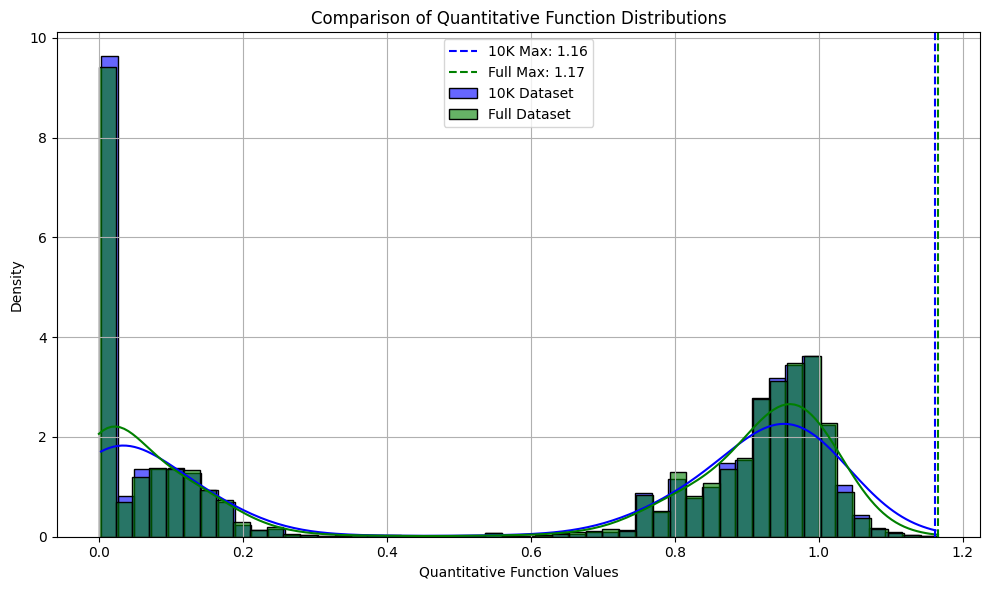

In [ ]:
# Load your datasets (adjust the paths as needed)
# Assuming the datasets are in CSV format with a column named 'quantitative_function'
dataset_10k = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/N00_raw_datasets_processed/GFP/sarkisyan_10ksampled.csv')
dataset_full = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/N00_raw_datasets_processed/GFP/sarkisyan.csv')

# Extract the 'quantitative_function' column
quant_10k = dataset_10k['quantitative_function']
quant_full = dataset_full['quantitative_function']

# Plot the histograms and KDEs for comparison
plt.figure(figsize=(10, 6))
sns.histplot(quant_10k, kde=True, color='blue', label='10K Dataset', stat='density', alpha=0.6, bins=50)
sns.histplot(quant_full, kde=True, color='green', label='Full Dataset', stat='density', alpha=0.6, bins=50)

# Highlight regions of interest (e.g., high or low values)
plt.axvline(x=quant_10k.max(), color='blue', linestyle='--', label=f'10K Max: {quant_10k.max():.2f}')
plt.axvline(x=quant_full.max(), color='green', linestyle='--', label=f'Full Max: {quant_full.max():.2f}')

# Add labels, legend, and title
plt.xlabel('Quantitative Function Values')
plt.ylabel('Density')
plt.title('Comparison of Quantitative Function Distributions')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()


# Save the plot
# Define the output folder
output_folder = Path("/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/plots")
output_folder.mkdir(parents=True, exist_ok=True)

output_file = os.path.join(output_folder, f"Distributions_comparison.png")
plt.savefig(output_file, dpi=300)
print(f"Plot saved to {output_file}")


plt.show()


In [ ]:
# def dataPrepFiles(data_folder= None, embedding_file= None, properties_file= None):
#     # Get Input files
#     print("\n>>> Getting all input files and splitting the data... ")
#     print("="*80)
#     #====================================================================================================#
#     # Get Sequence Embeddings from N03 pickles.
#     if data_folder is None:
#         data_folder = Path.cwd()
#     else:
#         data_folder = Path(data_folder)
#     print("embedding file path: ", data_folder / embedding_file)
#     if os.path.exists(data_folder / embedding_file):
#         print("Sequence embeddings found in one file.")
#         with open( data_folder / embedding_file, 'rb') as seqs_embeddings:
#             seqs_embeddings_pkl = pickle.load(seqs_embeddings)
#         try:
#             X_seqs_all_hiddens_list = seqs_embeddings_pkl['seq_all_hiddens']
#         except:
#             X_seqs_all_hiddens_list = seqs_embeddings_pkl['seqs_all_hiddens']
#         del(seqs_embeddings_pkl)
#     else:
#         print("Sequence embeddings found in mulitple files.")
#         #Marjan: just make double check to have embedding file as string here by adding "str(embedding_file)"
#         embedding_file_name = str(embedding_file).replace(".p", "")
#         embedding_file = str(embedding_file).replace(".p", "_0.p")
#         X_seqs_all_hiddens_list_full = []
#         while os.path.exists(data_folder / embedding_file):
#             print("File is readding is: " , embedding_file)
#             with open( data_folder / embedding_file, 'rb') as seqs_embeddings:
#                 seqs_embeddings_pkl = pickle.load(seqs_embeddings)
#             try:
#                 X_seqs_all_hiddens_list = seqs_embeddings_pkl['seq_all_hiddens']
#             except:
#                 X_seqs_all_hiddens_list = seqs_embeddings_pkl['seqs_all_hiddens']
#             del(seqs_embeddings_pkl)
#             X_seqs_all_hiddens_list_full = X_seqs_all_hiddens_list_full + X_seqs_all_hiddens_list
#             #del(X_seqs_all_hiddens_list)
#             next_index = str(int(embedding_file.replace(embedding_file_name + "_", "").replace(".p", "")) + 1)
#             embedding_file = embedding_file_name + "_" + next_index + ".p"

#         X_seqs_all_hiddens_list = copy.deepcopy(X_seqs_all_hiddens_list_full)
#         del X_seqs_all_hiddens_list_full
#     #====================================================================================================#
#     # Marjan: added if cluse for when we just need it without y values
#     # Get properties_list.
#     if properties_file is not None:
#         with open(data_folder / properties_file, 'rb') as seqs_properties:
#             properties_dict = pickle.load(seqs_properties)
#     else:
#         print(">>> properties_dict is None.....")
#         properties_dict = {}

#     return X_seqs_all_hiddens_list, properties_dict

In [7]:
import pickle
from pathlib import Path
import os

def dataPrepFiles(data_folder=None, embedding_file=None, chunk_size=1000):
    """
    Load sequence embeddings from large files in chunks to avoid memory issues.

    Parameters:
    - data_folder: Path to the folder containing embedding files
    - embedding_file: Name of the embedding file
    - chunk_size: Number of sequences to process at a time (default: 1000)

    Returns:
    - embeddings: List of sequence embeddings
    """
    data_folder = Path(data_folder)
    embedding_path = data_folder / embedding_file

    if embedding_path.exists():
        print(f"Embedding file path: {embedding_path}")
        with open(embedding_path, "rb") as file:
            seqs_embeddings_pkl = pickle.load(file)

        try:
            embeddings = seqs_embeddings_pkl["seq_all_hiddens"]
        except KeyError:
            embeddings = seqs_embeddings_pkl["seqs_all_hiddens"]

        return embeddings

    else:
        print("Embedding file found in multiple parts.")
        embeddings = []
        part_index = 0
        while True:
            part_file = f"{embedding_file.replace('.p', '')}_{part_index}.p"
            part_path = data_folder / part_file
            if not part_path.exists():
                break

            print(f"Reading file: {part_file}")
            with open(part_path, "rb") as part:
                seqs_embeddings_pkl = pickle.load(part)

            try:
                part_embeddings = seqs_embeddings_pkl["seq_all_hiddens"]
            except KeyError:
                part_embeddings = seqs_embeddings_pkl["seqs_all_hiddens"]

            embeddings.extend(part_embeddings)

            # If processing in chunks, yield results to reduce memory usage
            if len(embeddings) >= chunk_size:
                yield embeddings[:chunk_size]
                embeddings = embeddings[chunk_size:]

            part_index += 1

        # Return remaining embeddings
        if embeddings:
            yield embeddings


In [ ]:
# def dimensionality_reduction_and_save_plot(embedding_10k, embedding_full, method, output_folder):
#     """
#     Perform dimensionality reduction on sequence embeddings, visualize the distributions, and save the plots.

#     Parameters:
#     - embedding_10k: numpy array of sequence embeddings from the 10K dataset
#     - embedding_full: numpy array of sequence embeddings from the full dataset
#     - method: "tsne" or "pca" for dimensionality reduction
#     - output_folder: Path to save the output plots
#     """
#     if method == "tsne":
#         reducer = TSNE(n_components=2, random_state=42, perplexity=30)
#     elif method == "pca":
#         reducer = PCA(n_components=2)

#     # Combine embeddings
#     combined_embeddings = np.vstack((embedding_10k, embedding_full))
#     reduced_embeddings = reducer.fit_transform(combined_embeddings)

#     # Split back into 10K and full datasets
#     reduced_10k = reduced_embeddings[:len(embedding_10k)]
#     reduced_full = reduced_embeddings[len(embedding_10k):]

#     # Create output folder if it doesn't exist
#     os.makedirs(output_folder, exist_ok=True)

#     # Plot the 2D reduced embeddings
#     plt.figure(figsize=(10, 6))
#     plt.scatter(reduced_10k[:, 0], reduced_10k[:, 1], label='10K Dataset', alpha=0.6, s=20, c='blue')
#     plt.scatter(reduced_full[:, 0], reduced_full[:, 1], label='Full Dataset', alpha=0.6, s=20, c='green')
#     plt.title(f"{method.upper()} Visualization of Sequence Embeddings")
#     plt.xlabel("Component 1")
#     plt.ylabel("Component 2")
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()

#     # Save the plot
#     output_file = os.path.join(output_folder, f"{method.upper()}_embedding_visualization.png")
#     plt.savefig(output_file, dpi=300)
#     print(f"Plot saved to {output_file}")

#     plt.close()

In [ ]:
def dimensionality_reduction_and_save_plot(embedding_10k, embedding_full, method, output_folder):
    """
    Perform dimensionality reduction on sequence embeddings, visualize the distributions, and save the plots.

    Parameters:
    - embedding_10k: numpy array of sequence embeddings from the 10K dataset
    - embedding_full: numpy array of sequence embeddings from the full dataset
    - method: "tsne" or "pca" for dimensionality reduction
    - output_folder: Path to save the output plots
    """
    combined_embeddings = np.vstack((embedding_10k, embedding_full))
    n_samples = combined_embeddings.shape[0]

    if method == "tsne":
        # Set perplexity dynamically to be less than the number of samples
        perplexity = min(30, max(5, n_samples // 10))  # Adjust as needed
        print(f"Using perplexity={perplexity} for t-SNE with {n_samples} samples.")
        reducer = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    elif method == "pca":
        reducer = PCA(n_components=2)

    reduced_embeddings = reducer.fit_transform(combined_embeddings)

    reduced_10k = reduced_embeddings[:len(embedding_10k)]
    reduced_full = reduced_embeddings[len(embedding_10k):]

    os.makedirs(output_folder, exist_ok=True)

    plt.figure(figsize=(10, 6))
    plt.scatter(reduced_10k[:, 0], reduced_10k[:, 1], label="10K Dataset", alpha=0.6, s=20, c="blue")
    plt.scatter(reduced_full[:, 0], reduced_full[:, 1], label="Full Dataset", alpha=0.6, s=20, c="green")
    plt.title(f"{method.upper()} Visualization of Sequence Embeddings")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    output_file = os.path.join(output_folder, f"{method.upper()}_embedding_visualization.png")
    plt.savefig(output_file, dpi=300)
    print(f"Plot saved to {output_file}")

    plt.close()


In [6]:
def dimensionality_reduction_and_save_plot(embedding_10k, embedding_full, method, output_folder):
    """
    Perform dimensionality reduction on sequence embeddings, visualize the distributions, and save the plots.

    Parameters:
    - embedding_10k: numpy array of sequence embeddings from the 10K dataset
    - embedding_full: numpy array of sequence embeddings from the full dataset
    - method: "tsne" or "pca" for dimensionality reduction
    - output_folder: Path to save the output plots
    """
    combined_embeddings = np.vstack((embedding_10k, embedding_full))
    n_samples = combined_embeddings.shape[0]

    if n_samples < 2:
        print("Error: Not enough samples for dimensionality reduction.")
        return

    if method == "tsne":
        # Adjust perplexity dynamically
        if n_samples > 5:
            perplexity = min(30, max(5, n_samples // 10))
        else:
            perplexity = n_samples - 1  # Set perplexity to less than the number of samples
        print(f"Using perplexity={perplexity} for t-SNE with {n_samples} samples.")
        reducer = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    elif method == "pca":
        reducer = PCA(n_components=2)

    reduced_embeddings = reducer.fit_transform(combined_embeddings)

    reduced_10k = reduced_embeddings[:len(embedding_10k)]
    reduced_full = reduced_embeddings[len(embedding_10k):]

    os.makedirs(output_folder, exist_ok=True)

    plt.figure(figsize=(10, 6))
    plt.scatter(reduced_10k[:, 0], reduced_10k[:, 1], label="10K Dataset", alpha=0.6, s=20, c="blue")
    plt.scatter(reduced_full[:, 0], reduced_full[:, 1], label="Full Dataset", alpha=0.6, s=20, c="green")
    plt.title(f"{method.upper()} Visualization of Sequence Embeddings")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    output_file = os.path.join(output_folder, f"{method.upper()}_embedding_visualization.png")
    plt.savefig(output_file, dpi=300)
    print(f"Plot saved to {output_file}")

    plt.close()


In [ ]:
# Use the provided dataPrepFiles function to load the embeddings
data_folder = "/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing"
embedding_file_full = "N03_sarkisyan_embedding_ESM_1B.p"
embedding_file_10k = "N03_sarkisyan_10ksampled_embedding_ESM_1B.p"

# Load embeddings for the full dataset
full_embeddings_generator = dataPrepFiles(data_folder, embedding_file_full, chunk_size=5000)
full_sark_embeddings = []
for chunk in full_embeddings_generator:
    full_sark_embeddings.extend(chunk)

# Load embeddings for the 10K dataset
tenk_embeddings_generator = dataPrepFiles(data_folder, embedding_file_10k, chunk_size=5000)
tenk_sark_embeddings = []
for chunk in tenk_embeddings_generator:
    tenk_sark_embeddings.extend(chunk)

# Convert embeddings to numpy arrays
import numpy as np
full_sark_embeddings = np.array(full_sark_embeddings)
tenk_sark_embeddings = np.array(tenk_sark_embeddings)

# Define the output folder
output_folder = Path("/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/plots")
output_folder.mkdir(parents=True, exist_ok=True)


# Call the dimensionality reduction and save function
dimensionality_reduction_and_save_plot(tenk_sark_embeddings, full_sark_embeddings, method="tsne", output_folder=output_folder)
dimensionality_reduction_and_save_plot(tenk_sark_embeddings, full_sark_embeddings, method="pca", output_folder=output_folder)

Embedding file found in multiple parts.
Reading file: N03_sarkisyan_embedding_ESM_1B_0.p
Reading file: N03_sarkisyan_embedding_ESM_1B_1.p


In [ ]:
print(f"10K Embeddings Shape: {tenk_sark_embeddings.shape}")
print(f"Full Embeddings Shape: {full_sark_embeddings.shape}")
print(f"10K Embeddings Sample: {tenk_sark_embeddings[:5]}")
print(f"Full Embeddings Sample: {full_sark_embeddings[:5]}")


10K Embeddings Shape: (0,)
Full Embeddings Shape: (0,)
10K Embeddings Sample: []
Full Embeddings Sample: []


In [5]:
with open("/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/N03_sarkisyan_embedding_ESM_1B_0.p", "rb") as f:
    data = pickle.load(f)
    print(data.keys())


KeyboardInterrupt: 

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
